# DGI Embeddings for Contig Binning

Deep Graph Infomax is especially relevant because RepBin uses a DGI-like encoder/discriminator stage. This variant trains a GCN encoder to distinguish real contig features from shuffled corruptions, with marker cannot-link regularization.

This notebook runs the test dataset 10 times with different seeds, records all metrics for every run, prints min/max/mean/std, and plots mean metric values with standard-deviation error bars. Labels are used only after clustering to evaluate the bins. Node features use the RepBin-like representation: adjacency row + 136 TNF + coverage. The number of clusters is estimated from `contigs.fasta.markers`.

If dependencies are missing in a fresh environment, run:

```python
%pip install agtools torch scikit-learn biopython numpy pandas matplotlib scipy
```

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from graph_binning_common import *

DATA_DIR = REPO_ROOT / 'tests' / 'data'
SEED = 7
N_RUNS = 10
set_seed(SEED)


In [2]:
data = load_spades_dataset(DATA_DIR)
print_dataset_summary(data)

features = data['features']
adjacency = data['adjacency']
marker_pairs = data['marker_pairs']
labels = data['labels']
label_names = data['label_names']
N_CLUSTERS = data['marker_cluster_count']
print(f'k for clustering from marker genes: {N_CLUSTERS}')
print(f'marker cannot-link pairs: {len(marker_pairs)}')
print(data['feature_names'][:3], '...', data['feature_names'][-3:])


contigs: 509
edges: 1033
features: 646 (509 adjacency + 136 TNF + coverage)
marker sets: 91
marker-derived k: 5
Acetobacter_pasteurianus: 118
Aeromonas_veronii: 72
Amycolatopsis_mediterranei: 105
Arthrobacter_arilaitensis: 195
Azorhizobium_caulinodans: 19
k for clustering from marker genes: 5
marker cannot-link pairs: 1820
['adjacency_to_node_0', 'adjacency_to_node_1', 'adjacency_to_node_2'] ... ['TGCA', 'TTAA', 'log1p_coverage_zscore']


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

METHOD_NAME = 'DGI'

class DGIEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=96, embedding_dim=32, dropout=0.25):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim, bias=False)
        self.lin2 = nn.Linear(hidden_dim, embedding_dim, bias=False)
        self.dropout = dropout

    def forward(self, x, adjacency):
        a_hat = normalized_adjacency(adjacency.numpy(), mode='symmetric')
        a_hat = torch.tensor(a_hat, dtype=torch.float32, device=x.device)
        h = F.relu(a_hat @ self.lin1(x))
        h = F.dropout(h, p=self.dropout, training=self.training)
        z = a_hat @ self.lin2(h)
        return F.normalize(z, p=2, dim=1)

class DGIModel(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.encoder = DGIEncoder(in_dim)
        self.discriminator = nn.Bilinear(32, 32, 1)

    def score(self, z, summary):
        expanded = summary.expand_as(z)
        return self.discriminator(z, expanded).squeeze(1)

def train_dgi(seed, epochs=250, patience=35, lr=0.005, constraint_weight=0.25):
    set_seed(seed)
    x = torch.tensor(features, dtype=torch.float32)
    adj = torch.tensor(adjacency, dtype=torch.float32)
    pairs = torch.tensor(marker_pairs, dtype=torch.long) if len(marker_pairs) else None
    model = DGIModel(features.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    best_state, best_loss, wait = None, float('inf'), 0
    rng = np.random.default_rng(seed)
    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        perm = torch.tensor(rng.permutation(x.shape[0]), dtype=torch.long)
        z_pos = model.encoder(x, adj)
        z_neg = model.encoder(x[perm], adj)
        summary = torch.sigmoid(z_pos.mean(dim=0, keepdim=True))
        logits = torch.cat([model.score(z_pos, summary), model.score(z_neg, summary)])
        targets = torch.cat([torch.ones(x.shape[0]), torch.zeros(x.shape[0])])
        loss = F.binary_cross_entropy_with_logits(logits, targets)
        if pairs is not None:
            loss = loss + constraint_weight * torch.exp(-F.pairwise_distance(z_pos[pairs[:, 0]], z_pos[pairs[:, 1]], p=2)).mean()
        loss.backward()
        opt.step()
        current = float(loss.item())
        if current < best_loss - 1e-5:
            best_loss = current
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        embeddings = model.encoder(x, adj).cpu().numpy()
    return embeddings, {'epoch': epoch, 'loss': best_loss}

def run_once(seed):
    embeddings, history = train_dgi(seed)
    predictions, metrics = run_kmeans(embeddings, labels, seed=seed, n_clusters=N_CLUSTERS)
    metrics.update({'epochs': history['epoch'], 'loss': history['loss']})
    return metrics


run 01 seed=7: precision=0.9587, recall=0.9587, f1=0.9587, ari=0.9163, nmi=0.8928
run 02 seed=8: precision=0.9804, recall=0.9804, f1=0.9804, ari=0.9459, nmi=0.9427
run 03 seed=9: precision=0.9823, recall=0.9823, f1=0.9823, ari=0.9533, nmi=0.9404
run 04 seed=10: precision=0.9843, recall=0.9843, f1=0.9843, ari=0.9564, nmi=0.9484
run 05 seed=11: precision=0.9745, recall=0.9745, f1=0.9745, ari=0.9258, nmi=0.9241
run 06 seed=12: precision=0.9921, recall=0.9921, f1=0.9921, ari=0.9765, nmi=0.9749
run 07 seed=13: precision=0.9804, recall=0.9804, f1=0.9804, ari=0.9467, nmi=0.9422
run 08 seed=14: precision=0.9194, recall=0.8350, f1=0.8752, ari=0.7202, nmi=0.8134
run 09 seed=15: precision=0.9293, recall=0.8841, f1=0.9061, ari=0.7896, nmi=0.8406
run 10 seed=16: precision=0.9568, recall=0.9568, f1=0.9568, ari=0.9068, nmi=0.9027


,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,1,7,0.958743,0.958743,0.958743,0.916263,0.892812,5,5,0.928644,250,0.067183
1,2,8,0.980354,0.980354,0.980354,0.945865,0.942737,5,5,0.980175,113,0.072391
2,3,9,0.982318,0.982318,0.982318,0.953291,0.940448,5,5,0.980013,70,0.092300
3,4,10,0.984283,0.984283,0.984283,0.956390,0.948421,5,5,0.986496,91,0.084902
4,5,11,0.974460,0.974460,0.974460,0.925773,0.924072,5,5,0.980582,150,0.077316
5,6,12,0.992141,0.992141,0.992141,0.976461,0.974852,5,5,0.994086,190,0.075499
6,7,13,0.980354,0.980354,0.980354,0.946723,0.942194,5,5,0.983452,153,0.071445
7,8,14,0.919450,0.834971,0.875176,0.720166,0.813408,5,5,0.800621,131,0.076287
8,9,15,0.929273,0.884086,0.906117,0.789594,0.840598,5,5,0.836964,151,0.073867
9,10,16,0.956778,0.956778,0.956778,0.906754,0.902736,5,5,0.919684,174,0.068747


,min,max,mean,std
precision,0.919450,0.992141,0.965815,0.024542
recall,0.834971,0.992141,0.952849,0.051698
f1,0.875176,0.992141,0.959072,0.038384
ari,0.720166,0.976461,0.903728,0.082676
nmi,0.813408,0.974852,0.912228,0.050947
aligned_macro_f1,0.800621,0.994086,0.939072,0.068648


<Axes: title={'center': 'DGI: mean metrics over 10 runs'}, ylabel='score'>

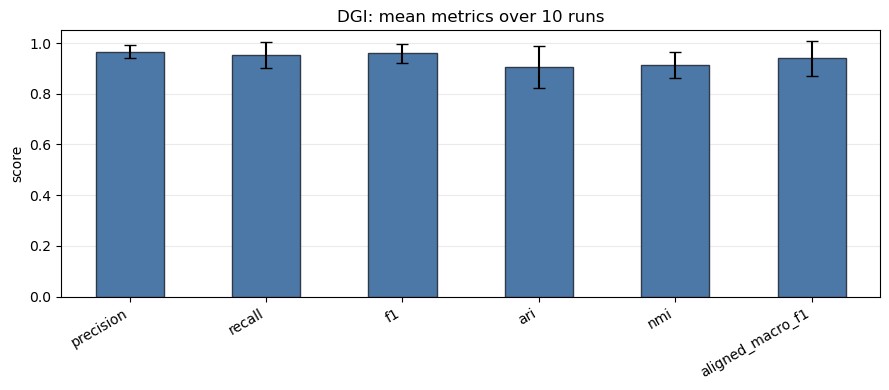

In [4]:
results = run_repeated_experiment(run_once, n_runs=N_RUNS, seed=SEED)
summary = summarize_metric_table(results)

display(results)
display(summary)
plot_metric_bars(summary, title=f'{METHOD_NAME}: mean metrics over {N_RUNS} runs')


## Assembly graph coloured by predicted bin

This plot reruns the method once on the original test graph using `SEED`, captures that method's KMeans bin assignments, and colours contigs in the igraph assembly graph by the predicted bin.

{'precision': 0.9587426326129665, 'recall': 0.9587426326129665, 'f1': 0.9587426326129665, 'ari': 0.9162630554478713, 'nmi': 0.8928115695480806, 'n_bins_predicted': 5, 'n_true_bins': 5, 'aligned_macro_f1': 0.9286438067111572, 'epochs': 250, 'loss': 0.06759575754404068}
DGI: assembly graph coloured by predicted bin
bin 0: 96 contigs
bin 1: 30 contigs
bin 2: 187 contigs
bin 3: 73 contigs
bin 4: 123 contigs


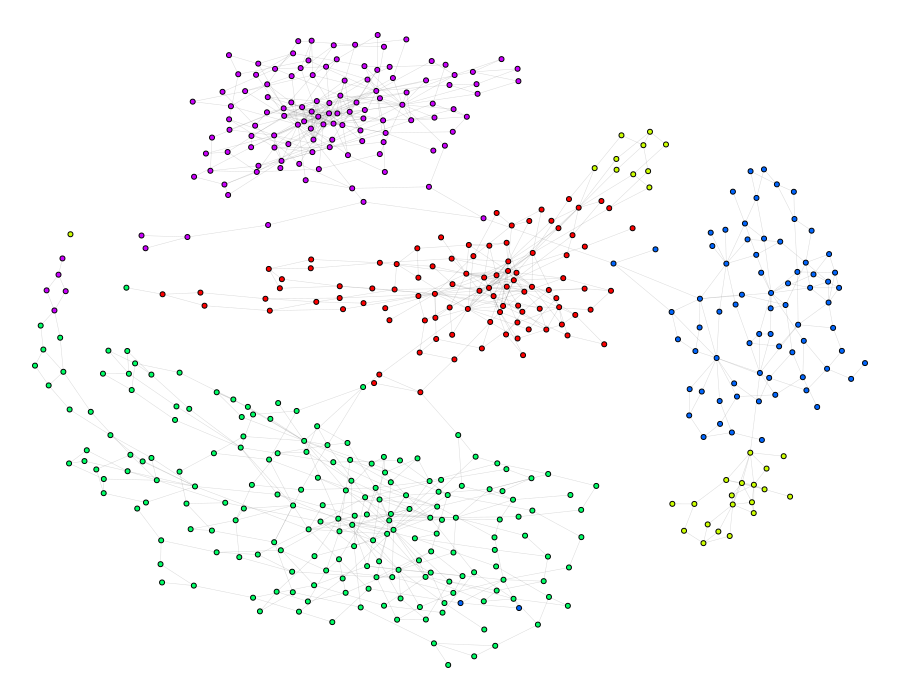

In [5]:
_visual_predictions = None
_original_run_kmeans = run_kmeans

def _capture_run_kmeans(embeddings, labels, seed=7, n_clusters=None):
    global _visual_predictions
    predictions, metrics = _original_run_kmeans(embeddings, labels, seed=seed, n_clusters=n_clusters)
    _visual_predictions = predictions
    return predictions, metrics

run_kmeans = _capture_run_kmeans
try:
    visual_metrics = run_once(SEED)
finally:
    run_kmeans = _original_run_kmeans

print(visual_metrics)
plot_assembly_graph_bins(
    data,
    bins=_visual_predictions,
    title=f'{METHOD_NAME}: assembly graph coloured by predicted bin',
)


## Graph corruption / ablation study

This section reruns the same method under five graph conditions: original assembly graph, random edge removal, random edge addition, coverage-similarity edges added, and short contigs removed. Each condition is run with the same 10 seeds, then metrics are summarized and plotted with standard-deviation error bars.

ablation: original assembly graph
ablation: random edge removal
ablation: random edge addition
ablation: coverage-similarity edges added
ablation: short contigs removed


,ablation,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,original assembly graph,1,7,0.958743,0.958743,0.958743,0.916263,0.892812,5,5,0.928644,250,0.067454
1,original assembly graph,2,8,0.980354,0.980354,0.980354,0.945865,0.942737,5,5,0.980175,113,0.072391
2,original assembly graph,3,9,0.982318,0.982318,0.982318,0.953291,0.940448,5,5,0.980013,70,0.092300
3,original assembly graph,4,10,0.984283,0.984283,0.984283,0.956390,0.948421,5,5,0.986496,91,0.084902
4,original assembly graph,5,11,0.974460,0.974460,0.974460,0.925773,0.924072,5,5,0.980582,150,0.077243
5,original assembly graph,6,12,0.992141,0.992141,0.992141,0.976461,0.974852,5,5,0.994086,190,0.075499
6,original assembly graph,7,13,0.980354,0.980354,0.980354,0.946723,0.942194,5,5,0.983452,153,0.071445
7,original assembly graph,8,14,0.919450,0.834971,0.875176,0.720166,0.813408,5,5,0.800621,131,0.076287
8,original assembly graph,9,15,0.929273,0.884086,0.906117,0.789594,0.840598,5,5,0.836964,151,0.073867
9,original assembly graph,10,16,0.956778,0.956778,0.956778,0.906754,0.902736,5,5,0.919684,174,0.068751


precision                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.919450  0.992141  0.965815  0.024542   
random edge removal              0.868369  0.960707  0.926130  0.031505   
random edge addition             0.884086  0.950884  0.921022  0.019200   
coverage-similarity edges added  0.825147  0.878193  0.856582  0.017499   
short contigs removed            0.920000  0.971111  0.946222  0.019815   

                                   recall                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.834971  0.992141  0.952849  0.051698   
random edge removal              0.801572  0.960707  0.899018  0.066082   
random edge addition             0.856582  0.950884  0.916699  0.027679   
coverage-similarity edges added  0.825147  0.878193  0.856582  0.017499   
short contigs removed            0.857778  0.971111  0.934889  0.039434   

                                       f1            ...       ari            \
                                      min       max  ...      mean       std   
ablation                                             ...                       
original assembly graph          0.875176  0.992141  ...  0.903728  0.082676   
random edge removal              0.833635  0.960707  ...  0.794544  0.103968   
random edge addition             0.870117  0.950884  ...  0.797546  0.053262   
coverage-similarity edges added  0.825147  0.878193  ...  0.655275  0.034699   
short contigs removed            0.887800  0.971111  ...  0.860097  0.062092   

                                      nmi                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.813408  0.974852  0.912228  0.050947   
random edge removal              0.688499  0.879237  0.810776  0.058519   
random edge addition             0.712562  0.846740  0.782283  0.037679   
coverage-similarity edges added  0.630844  0.704984  0.674543  0.024171   
short contigs removed            0.815449  0.924345  0.866276  0.036776   

                                aligned_macro_f1                                
                                             min       max      mean       std  
ablation                                                                        
original assembly graph                 0.800621  0.994086  0.939072  0.068648  
random edge removal                     0.759870  0.953916  0.878780  0.080439  
random edge addition                    0.815854  0.945235  0.900738  0.040787  
coverage-similarity edges added         0.795519  0.869572  0.840239  0.024050  
short contigs removed                   0.815586  0.977697  0.918275  0.056601  

[5 rows x 24 columns]

<Axes: title={'center': 'DGI: graph corruption / ablation study'}, xlabel='ablation', ylabel='score'>

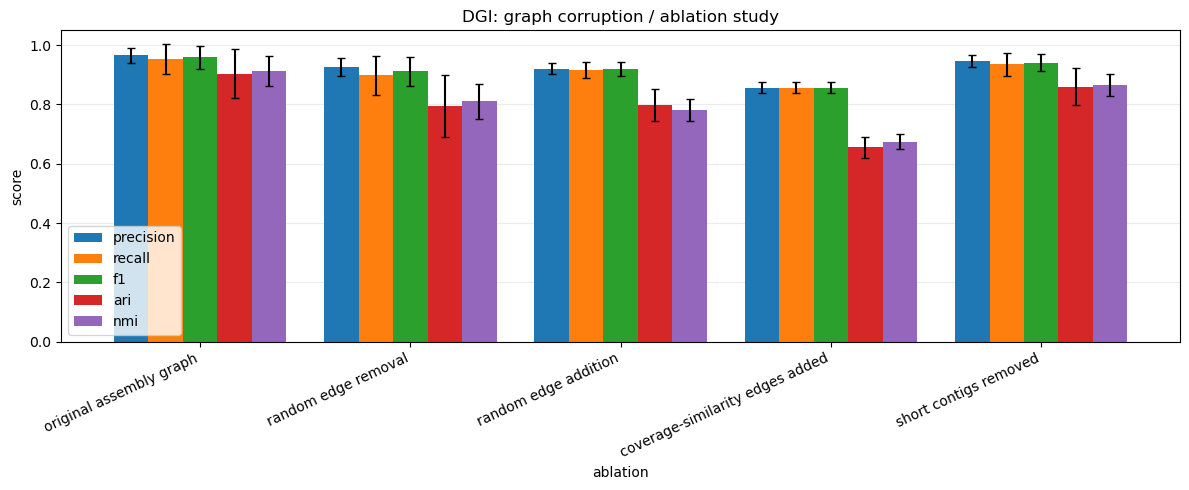

In [6]:
def run_once_ablation(seed, ablation_data):
    global features, adjacency, marker_pairs, labels, label_names, N_CLUSTERS, spectral_embeddings

    old_state = {
        'features': features,
        'adjacency': adjacency,
        'marker_pairs': marker_pairs,
        'labels': labels,
        'label_names': label_names,
        'N_CLUSTERS': N_CLUSTERS,
        'spectral_embeddings': globals().get('spectral_embeddings', None),
    }
    try:
        features = ablation_data['features']
        adjacency = ablation_data['adjacency']
        marker_pairs = ablation_data['marker_pairs']
        labels = ablation_data['labels']
        label_names = ablation_data['label_names']
        N_CLUSTERS = ablation_data['marker_cluster_count']

        # The Laplacian Eigenmaps notebook precomputes graph embeddings outside
        # run_once, so recompute them when the graph changes.
        if 'laplacian_eigenmap_embeddings' in globals():
            spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

        return run_once(seed)
    finally:
        features = old_state['features']
        adjacency = old_state['adjacency']
        marker_pairs = old_state['marker_pairs']
        labels = old_state['labels']
        label_names = old_state['label_names']
        N_CLUSTERS = old_state['N_CLUSTERS']
        if old_state['spectral_embeddings'] is not None:
            spectral_embeddings = old_state['spectral_embeddings']

ablation_results, ablation_summary = run_graph_ablation_study(
    data,
    run_once_ablation,
    n_runs=N_RUNS,
    seed=SEED,
)

display(ablation_results)
display(ablation_summary)
plot_ablation_metric_bars(ablation_summary, title=f'{METHOD_NAME}: graph corruption / ablation study')
